<a href="https://colab.research.google.com/github/Ladyjinxxx/codveda-machine-learning-internship/blob/main/Level2_Task3_KMeans_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Level 2 - Task 2: K-Means Clustering
### Codveda Technologies Machine Learning Internship

**Dataset:** Customer Churn

In [1]:
# Cell 1: Mount Google Drive
# Connects this notebook to Google Drive so we can access the dataset and save outputs.

from google.colab import drive
drive.mount('/content/drive')

# Set the main project folder path
project_path = '/content/drive/MyDrive/Codveda_Internship/Level2_Task3_KMeans_Churn'

Mounted at /content/drive


In [2]:
# Cell 2: Install Libraries
# Colab already comes with pandas, numpy, matplotlib, seaborn, and scikit-learn pre-installed.
# No additional installation is needed, so this cell just upgrades scikit-learn to be safe.

!pip install -q --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.2 MB/s eta 0:00:00


In [3]:
# Cell 3: Import Libraries
# Only the libraries actually used in this notebook are imported.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_style('whitegrid')

In [4]:
# Cell 4: Define File Paths
# Set up the dataset path and organize outputs into clear subfolders.

base_path = Path(project_path)
dataset_path = base_path / 'churn-bigml-80.csv'

output_path = base_path / 'outputs'
charts_path = output_path / 'charts'
tables_path = output_path / 'tables'
model_path = output_path / 'model'

# Create the output folders if they don't already exist
for folder in [charts_path, tables_path, model_path]:
    folder.mkdir(parents=True, exist_ok=True)

In [5]:
# Cell 5: Load the Dataset
# Read the telecom customer churn dataset and take a first look at it.

df = pd.read_csv(dataset_path)

# First five rows give a quick preview of the actual values
print("First 5 rows:")
display(df.head())

# Shape tells us how many customers (rows) and features (columns) we have
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Column names show what information is available for each customer
print("\nColumn names:")
print(df.columns.tolist())

# Data types tell us which columns are numerical vs categorical/text
print("\nData types:")
print(df.dtypes)

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False



Dataset shape: 2666 rows, 20 columns

Column names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Data types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64

In [6]:
# Cell 6: Exploratory Data Analysis (EDA)
# Check data quality and get a general sense of the dataset before preprocessing.

# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Descriptive statistics for numerical columns
print("\nDescriptive statistics:")
display(df.describe())

# Count how many columns are numerical vs categorical
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"\nNumber of numerical variables: {len(numerical_cols)}")
print(f"Number of categorical variables: {len(categorical_cols)}")

Missing values per column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Number of duplicate rows: 0

Descriptive statistics:


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000



Number of numerical variables: 16
Number of categorical variables: 4


In [7]:
# Cell 7: Data Preprocessing
# Prepare the dataset so it can be used for K-Means clustering.

# 'State' and 'Area code' are location identifiers, not meaningful behavior patterns, so we drop them
# 'Churn' is kept aside for later interpretation but not used as a clustering feature
df_processed = df.drop(columns=['State', 'Area code'])

# Encode the two Yes/No categorical columns as 0/1
label_encoder = LabelEncoder()
df_processed['International plan'] = label_encoder.fit_transform(df_processed['International plan'])
df_processed['Voice mail plan'] = label_encoder.fit_transform(df_processed['Voice mail plan'])

# Keep the churn labels separate for later analysis, not for clustering itself
churn_labels = df_processed['Churn']

# Select the numerical features that describe customer usage behavior
cluster_features = [
    'Account length', 'International plan', 'Voice mail plan',
    'Number vmail messages', 'Total day minutes', 'Total day calls',
    'Total eve minutes', 'Total eve calls', 'Total night minutes',
    'Total night calls', 'Total intl minutes', 'Total intl calls',
    'Customer service calls'
]

X = df_processed[cluster_features]

# K-Means groups points based on distance, so features with larger numeric ranges
# (like call minutes) would dominate over smaller ones (like plan flags) if left unscaled.
# Scaling puts every feature on the same scale so each one contributes fairly to the distance calculation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features used for clustering: {len(cluster_features)}")
print(f"Scaled feature matrix shape: {X_scaled.shape}")

Features used for clustering: 13
Scaled feature matrix shape: (2666, 13)


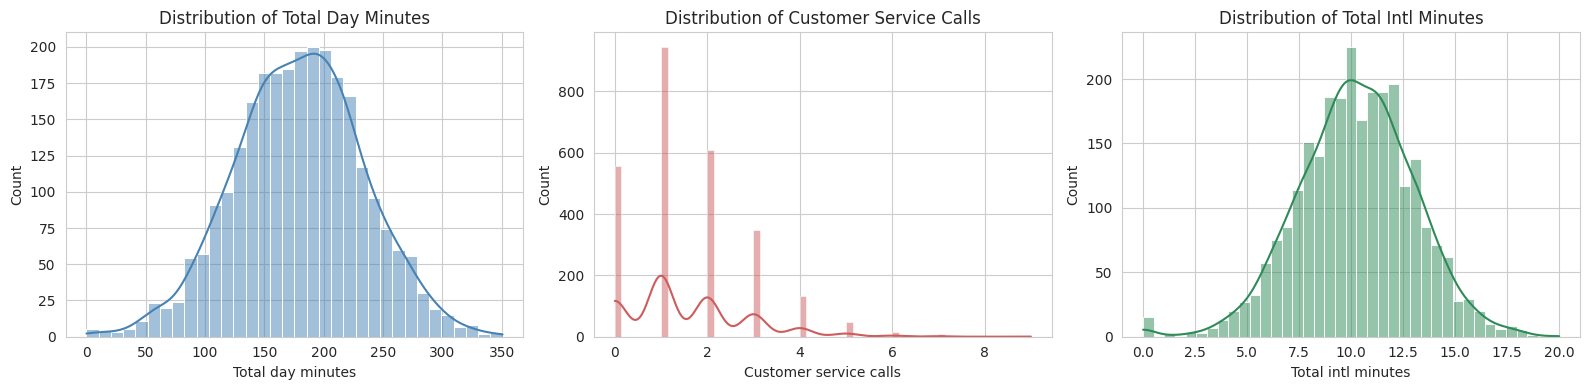

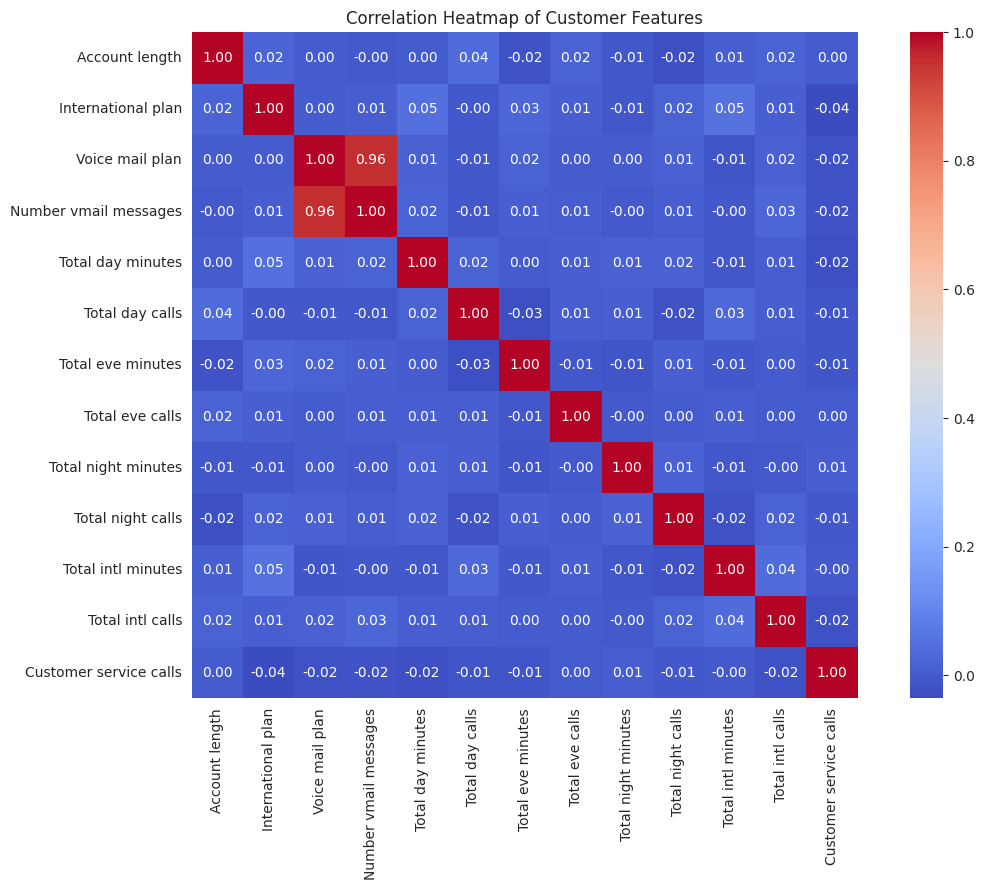

In [8]:
# Cell 8: Exploratory Visualizations
# Visualize a few important features and how they relate to each other.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['Total day minutes'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Total Day Minutes')

sns.histplot(df['Customer service calls'], kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Distribution of Customer Service Calls')

sns.histplot(df['Total intl minutes'], kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('Distribution of Total Intl Minutes')

plt.tight_layout()
plt.savefig(charts_path / 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap to see how numerical features relate to each other
plt.figure(figsize=(12, 9))
correlation_matrix = df_processed[cluster_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Customer Features')
plt.tight_layout()
plt.savefig(charts_path / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

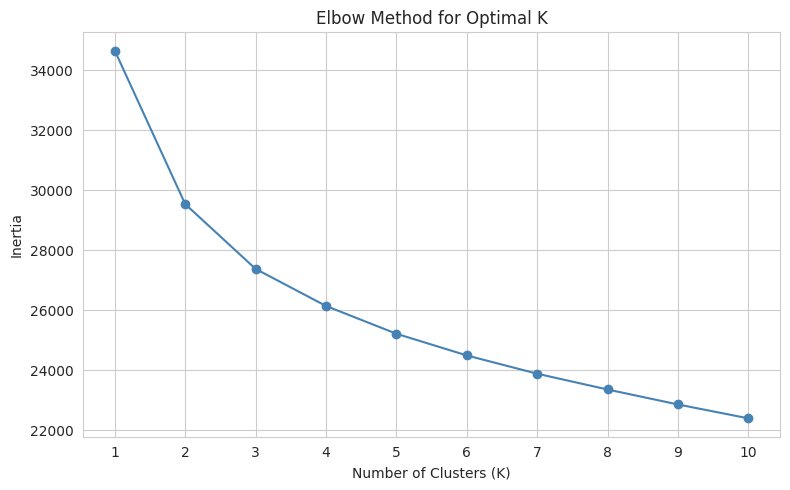

Selected number of clusters: 4


In [9]:
# Cell 9: Determine the Optimal Number of Clusters
# Use the Elbow Method to decide how many clusters (K) best represent the data.

# Inertia measures how tightly packed the points are within each cluster
# (the sum of squared distances between each point and its cluster center).
# Lower inertia means tighter clusters, but inertia always decreases as K increases,
# so we look for the point where adding more clusters stops giving a meaningful improvement.

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inertia_values.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig(charts_path / 'elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

# The elbow point is where the curve bends and starts flattening out,
# meaning extra clusters no longer reduce inertia by much.
# Based on the curve, K=4 is chosen as the optimal number of clusters.
optimal_k = 4
print(f"Selected number of clusters: {optimal_k}")

In [10]:
# Cell 10: Train the K-Means Model
# Train the final K-Means model using the selected number of clusters.

# random_state ensures the results are reproducible every time the notebook runs
# n_init controls how many times the algorithm runs with different centroid seeds,
# keeping the best result and avoiding poor local minima
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(X_scaled)

print("K-Means model trained successfully.")
print(f"Number of clusters: {optimal_k}")

K-Means model trained successfully.
Number of clusters: 4


In [11]:
# Cell 11: Assign Cluster Labels
# Attach each customer's predicted cluster back to the dataset.

df_processed['Cluster'] = kmeans_model.labels_

print("First 5 rows with cluster labels:")
display(df_processed.head())

print("\nNumber of customers per cluster:")
print(df_processed['Cluster'].value_counts().sort_index())

First 5 rows with cluster labels:


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Cluster
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,3
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,3
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,2
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,1
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1



Number of customers per cluster:
Cluster
0    845
1    270
2    893
3    658
Name: count, dtype: int64


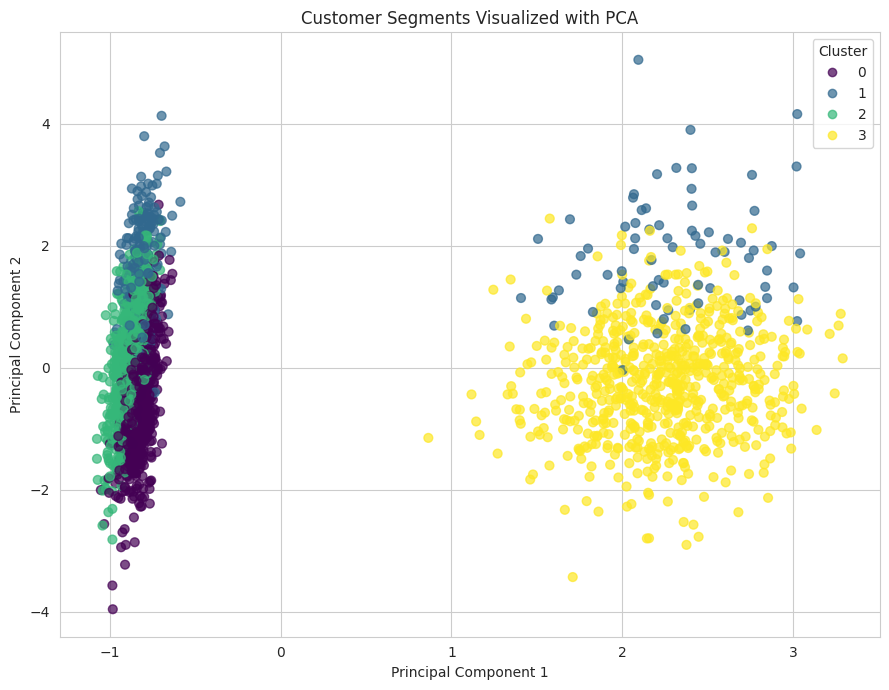

Variance explained by the 2 components: 23.70%


In [12]:
# Cell 12: Cluster Visualization
# Reduce the scaled features down to 2 dimensions with PCA so the clusters can be plotted.

# PCA is useful here because our dataset has many features, which can't be plotted directly.
# It compresses the data into 2 principal components that capture the most variance,
# making it possible to visualize how well-separated the clusters are.
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    pca_components[:, 0], pca_components[:, 1],
    c=df_processed['Cluster'], cmap='viridis', s=40, alpha=0.7
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments Visualized with PCA')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.savefig(charts_path / 'pca_cluster_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Variance explained by the 2 components: {pca.explained_variance_ratio_.sum():.2%}")

In [13]:
# Cell 13: Cluster Analysis
# Summarize the average feature values per cluster to understand what each group represents.

cluster_summary = df_processed.groupby('Cluster')[cluster_features].mean().round(2)

# Add churn rate per cluster for extra context (not used for clustering, just for interpretation)
cluster_summary['Churn rate'] = df_processed.groupby('Cluster').apply(
    lambda group: churn_labels.loc[group.index].mean()
).round(2)

display(cluster_summary)
cluster_summary.to_csv(tables_path / 'cluster_summary.csv')

# Interpretation is based directly on the averages shown above, not assumed in advance.
print("""
Cluster interpretation (based on the summary table above):

- Usage minutes (day/evening/night) are fairly similar across all four clusters,
  so the clusters are NOT simply separating heavy users from light users.

- Cluster 0: No international plan, no voicemail plan ("plain plan" customers).
  Shortest account length of the group. Moderate churn rate.

- Cluster 1: International plan customers (100% have the plan). This cluster
  stands out with a churn rate far above the others, making it the clearest
  at-risk segment in the dataset.

- Cluster 2: No international plan, no voicemail plan, longest average account
  length, and the highest average number of customer service calls. Lowest churn
  among the "plain plan" clusters.

- Cluster 3: Voicemail plan customers (100% have the plan, ~29 voicemail messages
  on average). This is the most loyal segment, with the lowest churn rate overall.

Overall, the clustering separated customers mainly by which optional plan they
are subscribed to (international plan vs. voicemail plan vs. neither), and this
split happens to line up closely with very different churn rates.
""")


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn rate
Cluster,,,,,,,,,,,,,,
0,81.21,0.0,0.00,0.00,190.46,92.09,210.35,98.54,198.53,107.63,9.48,4.37,1.55,0.15
1,103.51,1.0,0.28,8.26,187.48,100.06,204.43,100.64,199.61,101.15,10.68,4.55,1.42,0.44
2,118.18,0.0,0.00,0.00,166.62,108.58,188.72,101.15,204.47,92.54,10.94,4.51,1.64,0.12
3,100.53,0.0,1.00,29.11,179.56,99.76,201.77,100.15,200.73,100.29,10.07,4.50,1.53,0.05



Cluster interpretation (based on the summary table above):

- Usage minutes (day/evening/night) are fairly similar across all four clusters,
  so the clusters are NOT simply separating heavy users from light users.

- Cluster 0: No international plan, no voicemail plan ("plain plan" customers).
  Shortest account length of the group. Moderate churn rate.

- Cluster 1: International plan customers (100% have the plan). This cluster
  stands out with a churn rate far above the others, making it the clearest
  at-risk segment in the dataset.

- Cluster 2: No international plan, no voicemail plan, longest average account
  length, and the highest average number of customer service calls. Lowest churn
  among the "plain plan" clusters.

- Cluster 3: Voicemail plan customers (100% have the plan, ~29 voicemail messages
  on average). This is the most loyal segment, with the lowest churn rate overall.

Overall, the clustering separated customers mainly by which optional plan they
are subscrib

In [14]:
# Cell 14: Model Evaluation
# Review the clustering results to check whether the segmentation is reasonable.

print(f"Final inertia: {kmeans_model.inertia_:.2f}")

cluster_sizes = df_processed['Cluster'].value_counts().sort_index()
print("\nNumber of observations per cluster:")
print(cluster_sizes)

# A quick balance check: compare the smallest and largest cluster sizes
size_ratio = cluster_sizes.min() / cluster_sizes.max()
print(f"\nSmallest-to-largest cluster size ratio: {size_ratio:.2f}")
print("A ratio closer to 1.0 means the clusters are more evenly balanced.")
print("The PCA plot and cluster summary table both show reasonably distinct groups,")
print("suggesting the clustering captured meaningful patterns in customer behavior.")

Final inertia: 26149.77

Number of observations per cluster:
Cluster
0    845
1    270
2    893
3    658
Name: count, dtype: int64

Smallest-to-largest cluster size ratio: 0.30
A ratio closer to 1.0 means the clusters are more evenly balanced.
The PCA plot and cluster summary table both show reasonably distinct groups,
suggesting the clustering captured meaningful patterns in customer behavior.


In [15]:
# Cell 15: Final Conclusion
# Summary of what this notebook accomplished.

print("""
CONCLUSION

K-Means clustering was used to segment telecom customers into distinct groups
based on their usage behavior and plan subscriptions, without using the churn
label during training.

The Elbow Method identified 4 clusters as a good balance between simplicity
and capturing meaningful structure in the data. After scaling the features
and training the model, PCA was used to visualize the clusters in 2D, showing
reasonably distinct customer groups.

Contrary to what might be expected, the clusters did not separate customers by
usage intensity (day/evening/night minutes were similar across all groups).
Instead, the clustering picked up on plan subscriptions: one cluster of
international plan customers, one cluster of voicemail plan customers, and two
clusters of customers with neither plan.

The most important finding came from comparing churn rates across these groups:
the international plan cluster churns at roughly 44%, far higher than the
5-15% churn rates seen in the other three clusters. This was not something the
model was told to find - it emerged naturally from grouping customers by their
usage and plan patterns, and it lines up with a real, actionable business signal.

Possible business applications include:
- Reviewing the international plan (pricing, call quality, or terms), since its
  subscribers churn at a much higher rate than any other segment
- Prioritizing retention outreach toward international plan customers specifically
- Studying why voicemail plan customers are the most loyal segment, and
  considering ways to encourage more customers to adopt it
- Monitoring the high customer-service-call cluster, since frequent contact can
  be an early indicator of dissatisfaction even where churn is currently low
""")



CONCLUSION

K-Means clustering was used to segment telecom customers into distinct groups
based on their usage behavior and plan subscriptions, without using the churn
label during training.

The Elbow Method identified 4 clusters as a good balance between simplicity
and capturing meaningful structure in the data. After scaling the features
and training the model, PCA was used to visualize the clusters in 2D, showing
reasonably distinct customer groups.

Contrary to what might be expected, the clusters did not separate customers by
usage intensity (day/evening/night minutes were similar across all groups).
Instead, the clustering picked up on plan subscriptions: one cluster of
international plan customers, one cluster of voicemail plan customers, and two
clusters of customers with neither plan.

The most important finding came from comparing churn rates across these groups:
the international plan cluster churns at roughly 44%, far higher than the
5-15% churn rates seen in the other th